# Motor Intention Detection — tache gng

Button press prediction from MRCP:
- **Positive**: `[-2 s, 0]` before each button press
- **Negative**: randomly sampled rest windows, ≥ 2 s before and ≥ 3 s after any press

Pipeline: `bandpass 0.5–4 Hz → CAR → EA (artifact-robust) → MRCP features → shrinkage LDA`

Leave-one-trial-out cross-validation.

In [180]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne.filter import filter_data
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

## Config

**Edit these four lines per subject.**

In [181]:
SUBJECT   = "9"
TACHE     = "gng"
ROOT      = f"../data/subject{SUBJECT}"
USE_CLEAN = False

# ── fixed params ──────────────────────────────────────────────────────────────
FS            = 250.0
EPOCH_S       = 2.0
N_EPOCH       = int(EPOCH_S * FS)
LATE_MS       = 200;   N_LATE       = int(LATE_MS / 1000 * FS)
LATE_SLOPE_MS = 500;   N_LATE_SLOPE = int(LATE_SLOPE_MS / 1000 * FS)
N_SEGS        = 8

PRE_SAFETY_S  = 2.0    # exclude before press from negatives
POST_SAFETY_S = 3.0    # exclude after press (covers post-movement beta rebound)
N_PRE_SAFE    = int(PRE_SAFETY_S  * FS)
N_POST_SAFE   = int(POST_SAFETY_S * FS)

CHANNEL_COLS  = [f"ch{i}" for i in range(1, 17)]   # ch1 … ch16
ALL_IDX       = list(range(16))
CHANNEL_NAMES = ["FP1","F3","F7","C3","T3","P3","T5","O1",
                 "FP2","F4","F8","C4","T4","P4","T6","O2"]
N_CH          = len(ALL_IDX)
SEED          = 42

print(f"Subject={SUBJECT}  TACHE={TACHE}")
print(f"N_EPOCH={N_EPOCH} ({EPOCH_S} s)  channels={N_CH}")
print(f"Safety: pre={PRE_SAFETY_S} s  post={POST_SAFETY_S} s")

Subject=9  TACHE=gng
N_EPOCH=500 (2.0 s)  channels=16
Safety: pre=2.0 s  post=3.0 s


## Load & Preprocess

Per session: `bandpass → CAR → Euclidean Alignment → central channels`

**EA**: whitens each session's spatial covariance to a common scale. Covariance is estimated from artifact-free samples only (|amplitude| ≤ 4 SD per channel), preventing a single noisy epoch from distorting the whitening for the whole session.

In [182]:
def euclidean_align(data, n_sd=4.0):
    """Whiten session data (N, C) using artifact-robust covariance."""
    ch_std    = data.std(axis=0, keepdims=True)
    clean     = data[(np.abs(data) <= n_sd * ch_std).all(axis=1)]
    if len(clean) < 100:
        clean = data  # fallback: too few clean samples
    R = (clean.T @ clean) / len(clean)
    R += 1e-8 * np.eye(R.shape[0])
    vals, vecs = np.linalg.eigh(R)
    vals = np.maximum(vals, 1e-10)
    R_isqrt = vecs @ np.diag(vals ** -0.5) @ vecs.T
    return (R_isqrt @ data.T).T.astype(np.float32)


suffix = "clean_" if USE_CLEAN else ""
trial_files = sorted(
    f for f in os.listdir(ROOT)
    if f.startswith(f"subject_{SUBJECT}_tache_{TACHE}_{suffix}trial_") and f.endswith(".csv")
)
assert trial_files, f"No trial files found in {ROOT}"
print(f"Found {len(trial_files)} trial(s)")

sessions = {}

for fname in trial_files:
    idx = int(fname.split("trial_")[-1].replace(".csv", ""))
    df  = pd.read_csv(f"{ROOT}/{fname}", sep=None, engine="python")

    raw_ts  = df["timestamp"].values
    raw_eeg = df[CHANNEL_COLS].values.astype(np.float64)
    btn     = df["button"].values

    # bandpass + CAR
    filt = filter_data(raw_eeg.T, FS, 0.5, 4.0, verbose=False).T
    filt -= filt.mean(axis=1, keepdims=True)

    # EA with artifact-robust covariance (no z-score)
    filt = euclidean_align(filt)

    eeg_c = filt[:, CENTRAL_IDX].astype(np.float32)
    sessions[idx] = (raw_ts, eeg_c, btn)

    presses = int((np.diff(np.concatenate([[0], btn])) == 1).sum())
    print(f"  trial_{idx}: {len(eeg_c):,} samples  {presses} presses")

AssertionError: No trial files found in ../data/subject9

## Epoch extraction

Positive: 2 s window ending at each press.

Negative: randomly sampled rest windows. Asymmetric safety margin (improvement 3) excludes 2 s before and 3 s after each press — the extra post-press margin covers the post-movement beta rebound (~1–2 s after press).

In [ ]:
def extract_epochs(trial_idx, rng):
    ts, data, btn = sessions[trial_idx]
    N = len(data)

    press_idx = np.where(np.diff(np.concatenate([[0], btn])) == 1)[0]
    pos_epochs, neg_epochs = [], []
    pos_times,  neg_times  = [], []

    for p in press_idx:
        start = p - N_EPOCH
        if start >= 0:
            pos_epochs.append(data[start:p])
            pos_times.append(ts[p])           # anchor = press time

    forbidden = np.zeros(N, dtype=bool)
    for p in press_idx:
        lo = max(0, p - N_PRE_SAFE - N_EPOCH)
        hi = min(N, p + N_POST_SAFE)
        forbidden[lo:hi] = True

    valid_starts = np.where(~forbidden[:N - N_EPOCH])[0]
    n_neg = min(len(pos_epochs), len(valid_starts))
    chosen = rng.choice(valid_starts, n_neg, replace=False)
    for s in chosen:
        neg_epochs.append(data[s:s + N_EPOCH])
        neg_times.append(ts[s + N_EPOCH // 2])   # anchor = window midpoint

    epochs = np.array(pos_epochs + neg_epochs, dtype=np.float32)
    labels = np.array([1]*len(pos_epochs) + [0]*len(neg_epochs), dtype=np.int8)
    times  = np.array(pos_times  + neg_times,  dtype=np.float64)
    return epochs, labels, times


_rng0 = np.random.default_rng(SEED)
all_raw, all_y, all_tid, all_ts = [], [], [], []
for idx in sorted(sessions):
    raw, y, times = extract_epochs(idx, _rng0)
    print(f"  trial_{idx}: {(y==1).sum()} pos  {(y==0).sum()} neg")
    all_raw.append(raw); all_y.append(y)
    all_tid.append(np.full(len(y), idx, dtype=np.int32))
    all_ts.append(times)

raw_all = np.concatenate(all_raw)
y_all   = np.concatenate(all_y)
t_all   = np.concatenate(all_tid)
ts_all  = np.concatenate(all_ts)
print(f"\nTotal: {len(y_all)} epochs  {y_all.sum()} pos  shape {raw_all.shape}")

  trial_0: 11 pos  11 neg
  trial_1: 33 pos  33 neg
  trial_2: 29 pos  29 neg
  trial_3: 31 pos  31 neg
  trial_4: 34 pos  34 neg
  trial_5: 32 pos  32 neg
  trial_6: 33 pos  33 neg
  trial_7: 33 pos  33 neg
  trial_8: 30 pos  30 neg
  trial_9: 31 pos  31 neg
  trial_10: 30 pos  30 neg
  trial_11: 30 pos  30 neg
  trial_12: 30 pos  30 neg
  trial_13: 31 pos  31 neg
  trial_14: 30 pos  30 neg
  trial_15: 29 pos  29 neg
  trial_16: 31 pos  31 neg
  trial_17: 30 pos  30 neg
  trial_18: 30 pos  30 neg
  trial_19: 30 pos  30 neg
  trial_20: 30 pos  30 neg
  trial_21: 30 pos  30 neg

Total: 1316 epochs  658 pos  shape (1316, 500, 16)


## Grand-average MRCP

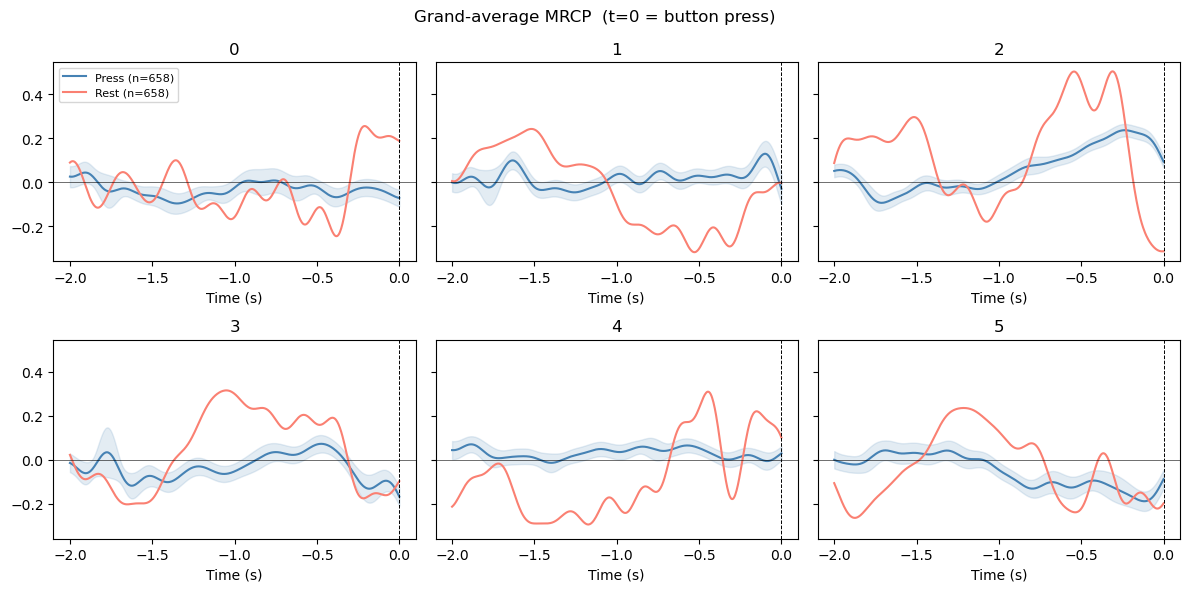

In [ ]:
%matplotlib inline

t_ax = np.linspace(-EPOCH_S, 0, N_EPOCH)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, (ch_i, ch_name) in zip(axes.flat, enumerate(CENTRAL_NAMES)):
    go_ep   = raw_all[y_all == 1][:, :, ch_i]
    rest_ep = raw_all[y_all == 0][:, :, ch_i]
    ax.plot(t_ax, go_ep.mean(0),   color="steelblue", label=f"Press (n={len(go_ep)})")
    ax.plot(t_ax, rest_ep.mean(0), color="salmon",    label=f"Rest (n={len(rest_ep)})")
    ax.fill_between(t_ax,
        go_ep.mean(0) - go_ep.std(0)/np.sqrt(len(go_ep)),
        go_ep.mean(0) + go_ep.std(0)/np.sqrt(len(go_ep)),
        alpha=0.15, color="steelblue")
    ax.axvline(0, color="k", linewidth=0.7, linestyle="--")
    ax.axhline(0, color="k", linewidth=0.4)
    ax.set_title(ch_name); ax.set_xlabel("Time (s)")
    if ch_i == 0: ax.legend(fontsize=8)

fig.suptitle("Grand-average MRCP  (t=0 = button press)")
plt.tight_layout(); plt.show()

## Features  (11 × 6 channels = 66 total)

In [ ]:
def epoch_features(epoch):
    T = epoch.shape[0]
    baseline = epoch[:int(0.1 * FS)].mean(axis=0)
    ep = epoch - baseline
    t_c = np.arange(T, dtype=np.float64) - T / 2

    feat_mean  = ep.mean(axis=0)
    feat_slope = (ep * t_c[:, None]).sum(axis=0) / (t_c**2).sum()

    seg_size  = T // N_SEGS
    feat_segs = np.stack(
        [ep[i*seg_size:(i+1)*seg_size].mean(axis=0) for i in range(N_SEGS)]
    ).T.flatten()

    feat_late = ep[-N_LATE:].mean(axis=0)

    ep_ls = ep[-N_LATE_SLOPE:]
    t_ls  = np.arange(N_LATE_SLOPE, dtype=np.float64) - N_LATE_SLOPE / 2
    feat_late_slope = (ep_ls * t_ls[:, None]).sum(axis=0) / (t_ls**2).sum()

    _, psd  = welch(ep.T, fs=FS, nperseg=min(T, 128))
    freqs   = np.fft.rfftfreq(min(T, 128), 1.0 / FS)
    feat_delta = psd[:, (freqs >= 0.5) & (freqs <= 4.0)].mean(axis=1)

    return np.concatenate([
        feat_mean, feat_slope, feat_segs, feat_late, feat_late_slope, feat_delta
    ]).astype(np.float32)


X_all = np.array([epoch_features(e) for e in raw_all])
print(f"Feature matrix: {X_all.shape}")

Feature matrix: (1316, 208)


## Leave-one-trial-out CV

In [ ]:
_rng = np.random.default_rng(SEED)
trial_ids = sorted(sessions.keys())

def balance(X, y, rng):
    idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
    n    = min(len(idx0), len(idx1))
    idx  = np.concatenate([rng.choice(idx0, n, replace=False),
                           rng.choice(idx1, n, replace=False)])
    return X[np.sort(idx)], y[np.sort(idx)]

def make_clf():
    return make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    )

fold_results = []
fold_preds   = []
all_probs    = []   # aggregated across folds for ROC
all_true     = []

for test_tid in trial_ids:
    tr = t_all != test_tid; te = t_all == test_tid
    X_tr_b, y_tr_b = balance(X_all[tr], y_all[tr], _rng)
    clf = make_clf(); clf.fit(X_tr_b, y_tr_b)
    prob = clf.predict_proba(X_all[te])[:, 1]
    auc  = roc_auc_score(y_all[te], prob)
    ap   = average_precision_score(y_all[te], prob)
    fold_results.append(dict(trial=test_tid, auc=auc, ap=ap))
    all_probs.append(prob)
    all_true.append(y_all[te])

    raw_ts, _, btn = sessions[test_tid]
    press_abs = raw_ts[np.where(np.diff(np.concatenate([[0], btn])) == 1)[0]]
    fold_preds.append(dict(
        trial    = test_tid,
        clf      = clf,
        press_ts = press_abs,
        t0       = raw_ts[0],
        auc      = auc,
    ))
    print(f"  trial_{test_tid}:  AUC={auc:.4f}  AP={ap:.4f}  "
          f"(train {y_tr_b.sum()} pos + {(y_tr_b==0).sum()} neg)")

all_probs = np.concatenate(all_probs)
all_true  = np.concatenate(all_true)
mean_auc  = np.mean([r['auc'] for r in fold_results])
std_auc   = np.std( [r['auc'] for r in fold_results])
mean_ap   = np.mean([r['ap']  for r in fold_results])
print(f"\nLOTO  AUC = {mean_auc:.4f} ±{std_auc:.4f}   AP = {mean_ap:.4f}")


  trial_0:  AUC=0.4132  AP=0.4712  (train 647 pos + 647 neg)
  trial_1:  AUC=0.6309  AP=0.6176  (train 625 pos + 625 neg)
  trial_2:  AUC=0.6314  AP=0.5837  (train 629 pos + 629 neg)
  trial_3:  AUC=0.5494  AP=0.5428  (train 627 pos + 627 neg)
  trial_4:  AUC=0.6289  AP=0.5542  (train 624 pos + 624 neg)
  trial_5:  AUC=0.6484  AP=0.6563  (train 626 pos + 626 neg)
  trial_6:  AUC=0.5712  AP=0.5221  (train 625 pos + 625 neg)
  trial_7:  AUC=0.7025  AP=0.6284  (train 625 pos + 625 neg)
  trial_8:  AUC=0.5522  AP=0.5904  (train 628 pos + 628 neg)
  trial_9:  AUC=0.5286  AP=0.5316  (train 627 pos + 627 neg)
  trial_10:  AUC=0.7278  AP=0.6174  (train 628 pos + 628 neg)
  trial_11:  AUC=0.6289  AP=0.5780  (train 628 pos + 628 neg)
  trial_12:  AUC=0.6811  AP=0.6832  (train 628 pos + 628 neg)


## Results

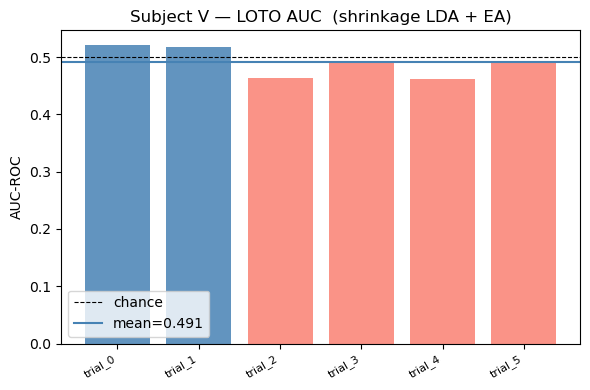

In [ ]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(max(6, len(fold_results)*1.0), 4))
tids   = [r["trial"] for r in fold_results]
aucs   = [r["auc"]   for r in fold_results]
colors = ["steelblue" if a >= 0.5 else "salmon" for a in aucs]
ax.bar(tids, aucs, color=colors, alpha=0.85)
ax.axhline(0.5,      color="k",         linestyle="--", linewidth=0.8, label="chance")
ax.axhline(mean_auc, color="steelblue", linestyle="-",  linewidth=1.5,
           label=f"mean={mean_auc:.3f}")
ax.set_xticks(tids)
ax.set_xticklabels([f"trial_{t}" for t in tids], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC")
ax.set_title(f"Subject {SUBJECT} — LOTO AUC  (shrinkage LDA + EA)")
ax.legend(); plt.tight_layout(); plt.show()

## Threshold Calibration

Aggregate ROC from all LOTO/LOSO folds — each epoch scored by the model
that never saw it during training.

Candidate thresholds:
- **Youden's J** — maximises sensitivity + specificity
- **Sens ≥ 0.80 / 0.90** — catch most presses
- **Spec ≥ 0.90 / 0.95** — low false-alarm rate (military priority)


In [ ]:
%matplotlib inline
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_true, all_probs)
spec = 1 - fpr

# candidate thresholds
j_idx      = np.argmax(tpr + spec - 1)                        # Youden's J
s80_idx    = np.argmax(tpr >= 0.80)                           # sens >= 0.80
s90_idx    = np.argmax(tpr >= 0.90)                           # sens >= 0.90
sp90_idx   = np.where(spec >= 0.90)[0][-1] if (spec >= 0.90).any() else 0
sp95_idx   = np.where(spec >= 0.95)[0][-1] if (spec >= 0.95).any() else 0

candidates = [
    ("Youden's J",   j_idx,    "steelblue"),
    ("Sens ≥ 0.80",  s80_idx,  "seagreen"),
    ("Sens ≥ 0.90",  s90_idx,  "limegreen"),
    ("Spec ≥ 0.90",  sp90_idx, "darkorange"),
    ("Spec ≥ 0.95",  sp95_idx, "tomato"),
]

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", linewidth=1.5,
        label=f"ROC  (AUC={mean_auc:.3f})")
ax.plot([0, 1], [0, 1], color="k", linewidth=0.6, linestyle="--")

for name, idx, color in candidates:
    ax.scatter(fpr[idx], tpr[idx], s=60, color=color, zorder=5,
               label=f"{name}  thr={thresholds[idx]:.3f}  "
                     f"sens={tpr[idx]:.2f}  spec={spec[idx]:.2f}")

ax.set_xlabel("False positive rate  (1 − specificity)")
ax.set_ylabel("True positive rate  (sensitivity)")
ax.set_title("Aggregate LOTO ROC — threshold calibration")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# summary table
print(f"{'Name':<14} {'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12}")
print("-" * 52)
for name, idx, _ in candidates:
    print(f"{name:<14} {thresholds[idx]:>10.3f} "
          f"{tpr[idx]:>12.3f} {spec[idx]:>12.3f}")


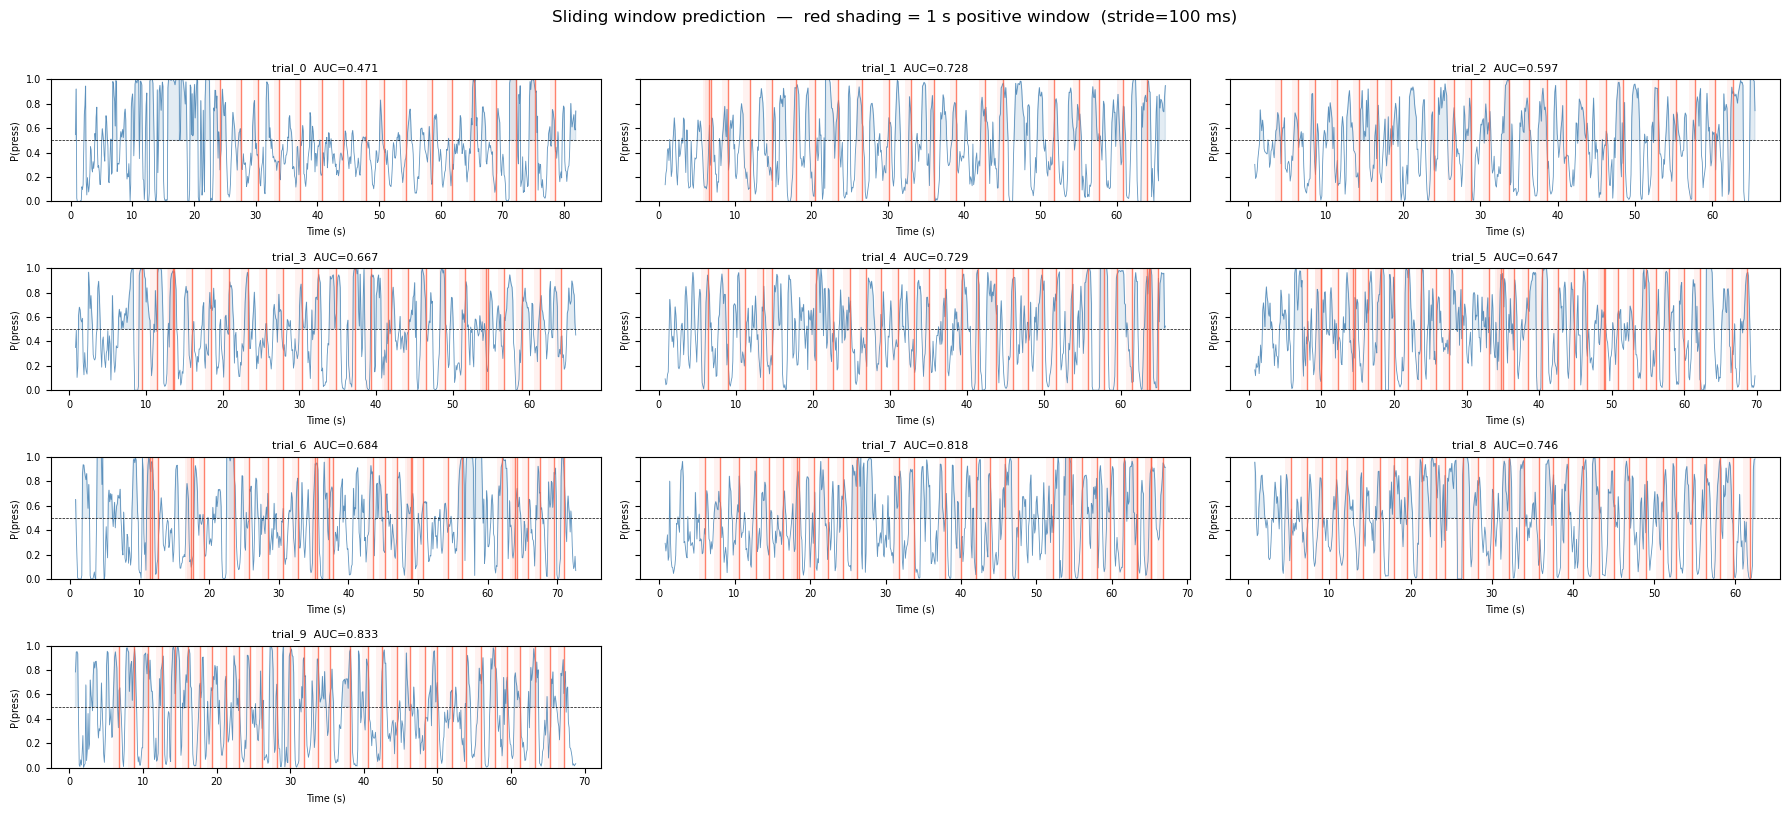

In [ ]:
%matplotlib inline

STRIDE = 25   # step between windows (100 ms at 250 Hz)

n_trials = len(fold_preds)
n_cols   = 3
n_rows   = int(np.ceil(n_trials / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 6, n_rows * 2.0),
                         sharey=True)
axes = np.array(axes).flatten()

for ax, fp in zip(axes, fold_preds):
    raw_ts, data, btn = sessions[fp["trial"]]
    clf_fold = fp["clf"]
    t0 = fp["t0"]

    # sliding window over full trial
    starts = np.arange(0, len(data) - N_EPOCH, STRIDE)
    feats  = np.array([epoch_features(data[s:s + N_EPOCH]) for s in starts])
    scores = clf_fold.predict_proba(feats)[:, 1]
    times  = (raw_ts[starts + N_EPOCH] - t0)

    # shaded positive epoch window before each press
    for pt in fp["press_ts"] - t0:
        ax.axvspan(pt - EPOCH_S, pt, color="tomato", alpha=0.08, linewidth=0)

    ax.plot(times, scores, color="steelblue", linewidth=0.6, alpha=0.85)
    ax.fill_between(times, 0.5, scores, where=scores > 0.5,
                    color="steelblue", alpha=0.15)
    ax.axhline(0.5, color="k", linewidth=0.5, linestyle="--")
    ax.set_ylim(0, 1)

    # button press lines
    for pt in fp["press_ts"] - t0:
        ax.axvline(pt, color="tomato", linewidth=1.0, alpha=0.8)

    ax.set_title(f"trial_{fp['trial']}  AUC={fp['auc']:.3f}", fontsize=8)
    ax.set_xlabel("Time (s)", fontsize=7)
    ax.set_ylabel("P(press)", fontsize=7)
    ax.tick_params(labelsize=7)

for ax in axes[n_trials:]:
    ax.set_visible(False)

fig.suptitle(
    f"Sliding window prediction  —  red shading = {EPOCH_S:.0f} s positive window  "
    f"(stride={STRIDE/FS*1000:.0f} ms)",
    y=1.01
)
plt.tight_layout()
plt.show()
